# 13_核方法-拉普拉斯核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。
- 拉普拉斯核分类器用标准估计器包装，保证交叉验证按原始特征拆分，随后分别构造训练核和验证核。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家聊聊核方法：拉普拉斯核\~

首先，什么是核方法（Kernel Method）？

想象你在二维平面上画了一堆点（这些点就是你的数据），你发现用一条直线很难把它们分开。那么怎么办呢？

**核方法的魔法就是：“把数据搬到一个更高维的空间”，在那个空间里就可能很容易把它们分开了！**

这就好像你在地上画了个圆圈，里面和外面的点分不清，但如果你把它们“提”到空中（比如Z轴），就能用一个平面分开了。

但不是真的搬数据，而是用一个叫**核函数**的“数学技巧”来**假装做了这件事**。

#### 什么是核函数？

核函数是一个公式，用来**计算两个数据偶先点之间在高维空间的“相似度”**，但你不需要知道高维空间长什么样，核函数会帮你搞定。

常见的核函数有：

- 线性核（Linear Kernel）：最基础，就像内积
- 高斯核（RBF核）：像“模糊的圆”
- 拉普拉斯核（Laplacian Kernel）：我们今天要聊的\~

#### 拉普拉斯核是什么？

先上公式：


$$
K(x, x') = \exp\left(-\frac{\|x - x'\|}{\sigma}\right)
$$


**这是什么意思？**

- $x$ 和 $x'$ 是两个数据点。
- $\|x - x'\|$ 表示它们之间的距离（越远值越大）。
- $\sigma$ 是一个参数，控制“模糊程度”。
- $\exp(-\text{某个数})$ 是指数函数，值会快速变小。

**通俗地说：**拉普拉斯核就是一个衡量“这两个点有多相似”的方法。**点越近，相似度越高，核函数值接近1；点越远，相似度越低，值接近0。**

跟高斯核类似，但有点区别：

- 高斯核用的是“距离的平方”，变化更平滑。
- 拉普拉斯核用的是“直接的距离”，变化更陡、更敏感。

## 原理详解

### 核方法

**线性可分与不可分**

许多传统分类器（如线性SVM）要求数据线性可分，即存在一个超平面能够将不同类别分开。但现实中，数据往往是**非线性分布的**。

**核技巧（Kernel Trick）**

为了解决非线性可分问题，可以将原始数据 $x \in \mathbb{R}^n$映射到一个高维特征空间：


$$
\phi: \mathbb{R}^n \rightarrow \mathcal{H}
$$


在高维空间中，使用线性模型即可拟合复杂的非线性关系。

但直接构造和计算高维映射 $\phi(x)$代价高昂，甚至不可行。因此，引入**核函数** $K(x, x')$，其定义为：  
$K(x, x') = \langle \phi(x), \phi(x') \rangle_{\mathcal{H}}$  
即：核函数等价于在高维空间中计算内积的结果，而无需显式知道 $\phi$。

### 拉普拉斯核

**拉普拉斯核的定义**

拉普拉斯核（Laplacian Kernel）是一种常用的径向基函数（Radial Basis Function，RBF），定义为：


$$
K(x, x') = \exp\left(-\frac{\|x - x'\|_1}{\sigma}\right)
$$


其中：

- $\|x - x'\|_1$是 L1 范数（曼哈顿距离）
- $\sigma > 0$是核宽度参数，控制相似度衰减速度

也有部分文献使用欧几里得距离：


$$
K(x, x') = \exp\left(-\frac{\|x - x'\|_2}{\sigma}\right)
$$


和高斯核的区别：

- 高斯核使用平方距离 $\|x - x'\|^2$，产生的是更平滑的函数；
- 拉普拉斯核使用线性距离 $\|x - x'\|$，对距离更敏感。

**为什么是这个形式？**

拉普拉斯核本质上来源于概率论中的**拉普拉斯分布**：


$$
p(x) = \frac{1}{2b} \exp\left(-\frac{|x - \mu|}{b}\right)
$$


其中：

- $\mu$是均值
- $b$是尺度参数

在核方法中，这种形式的核可以看作是：**样本点在以另一个点为中心、以** $\sigma$ **为尺度的拉普拉斯分布中的密度**。

因此，两个点之间的相似度就用这个密度值来衡量，自然得出：


$$
K(x, x') = \exp\left(-\frac{\|x - x'\|}{\sigma}\right)
$$


这个形式满足 Mercer 定理，是合法的核函数。

### 核方法中使用拉普拉斯核的流程（以 SVM 为例）

我们以支持向量机（SVM）为例，描述完整的算法流程。

#### 步骤 1：原始问题建模（线性 SVM）

给定训练数据：  
$\{(x_i, y_i)\}_{i=1}^n, \quad x_i \in \mathbb{R}^d, \quad y_i \in \{-1, 1\}$

线性SVM的目标函数为：  
$\min_{w,b,\xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i$  
约束条件：  
$y_i(w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$

#### 步骤 2：引入核函数

在非线性可分情况下，将 $x_i$通过 $\phi(x_i)$映射到高维空间，目标变为：  
$\min_{w,b,\xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i$  
$\text{s.t. } y_i(w^T \phi(x_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$

#### 步骤 3：对偶问题（Dual Form）

使用拉格朗日乘子法，可以将其转化为对偶问题：

$\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j=1}^n \alpha_i \alpha_j y_i y_j \underbrace{\langle \phi(x_i), \phi(x_j) \rangle}_{K(x_i, x_j)}$  
$\text{s.t. } 0 \le \alpha_i \le C, \quad \sum_{i=1}^n \alpha_i y_i = 0$

此时，只需要计算核函数 $K(x_i, x_j)$，不需要显式映射。

#### 步骤 4：使用拉普拉斯核计算核矩阵

对每一对训练样本 $x_i, x_j$，用拉普拉斯核计算核矩阵：  
$K_{ij} = \exp\left(-\frac{\|x_i - x_j\|}{\sigma}\right)$

这构成了对偶问题中的关键部分。通过求解拉格朗日对偶问题中的二次规划，即可得到最优解。

#### 步骤 5：构造决策函数

训练完成后，得到支持向量和对应的 $\alpha_i$，预测新样本 $x$的标签：  
$f(x) = \text{sign} \left( \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b \right)$

使用的就是拉普拉斯核函数：  
$K(x_i, x) = \exp\left(-\frac{\|x_i - x\|}{\sigma}\right)$

### 拉普拉斯核的性质分析

| 性质 | 内容 |
|-|-|
| 平滑性 | 相较于高斯核更敏感，变化更陡 |
| 支持度 | 远离中心的点迅速降权，更适合有清晰边界的分类任务 |
| 参数调控 | $\sigma$控制“衰减速度”，越小则相似度下降越快 |
| 正定性 | 满足 Mercer 条件，是合法核函数 |
| 计算复杂度 | 与其他核函数一致，为 $O(n^2)$ 计算核矩阵 |

## 完整案例

在现实场景中，很多分类任务面临非线性数据的挑战，例如语音识别中的频谱分析、图像边缘检测中的像素值分布等。

在这种情况下，传统线性分类器（如线性SVM）性能受限。

为解决非线性问题，「核方法」提供了一种强大而优雅的数学框架。

特别地，**拉普拉斯核**作为一种对「距离」更敏感的核函数，在处理有明显分类边界的任务中表现优异。

本项目将构建一个完整案例：

- 使用 `make_moons` 构造典型的非线性数据；
- 构造自定义的拉普拉斯核函数；
- 应用核SVM分类；
- 绘制分类结果、正确与错误样本可视化；
- 对分类性能进行全面分析；
- 使用网格搜索调参优化模型。

### 1. 数据生成与处理

使用 `make_moons` 构造两个半月形状的数据集，模拟非线性分布：

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=3000, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2. 定义拉普拉斯核函数

我们自定义一个核矩阵计算函数：

In [3]:
import numpy as np

def laplacian_kernel(X, Y, sigma=1.0):
    K = np.zeros((X.shape[0], Y.shape[0]))
    for i, x in enumerate(X):
        K[i, :] = np.exp(-np.sum(np.abs(x - Y), axis=1) / sigma)
    return K

**注意：** Sklearn 的 `SVC(kernel='precomputed')` 接受一个核矩阵，我们用这个技巧来注入自定义核函数。

### 3. SVM建模 + 自定义核训练

In [4]:
from sklearn.svm import SVC

sigma = 0.5
K_train = laplacian_kernel(X_train, X_train, sigma=sigma)

clf = SVC(kernel='precomputed', C=1.0)
clf.fit(K_train, y_train)

K_test = laplacian_kernel(X_test, X_train, sigma=sigma)
y_pred = clf.predict(K_test)

### 4. 性能评估与结果分析

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[449  21]
 [ 28 402]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       470
           1       0.95      0.93      0.94       430

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



输出内容如：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[[67  4]
 [ 6 73]]
              precision    recall  f1-score   support
           0       0.92      0.94      0.93        71
           1       0.95      0.92      0.93        79
```

- **Precision（精确率）**：被预测为该类中，有多少是真实属于该类的；
- **Recall（召回率）**：所有真实为该类的样本中，有多少被成功预测；
- **F1-score**：综合了精确率与召回率，是性能更稳健的评估指标。

### 5. 分类结果可视化

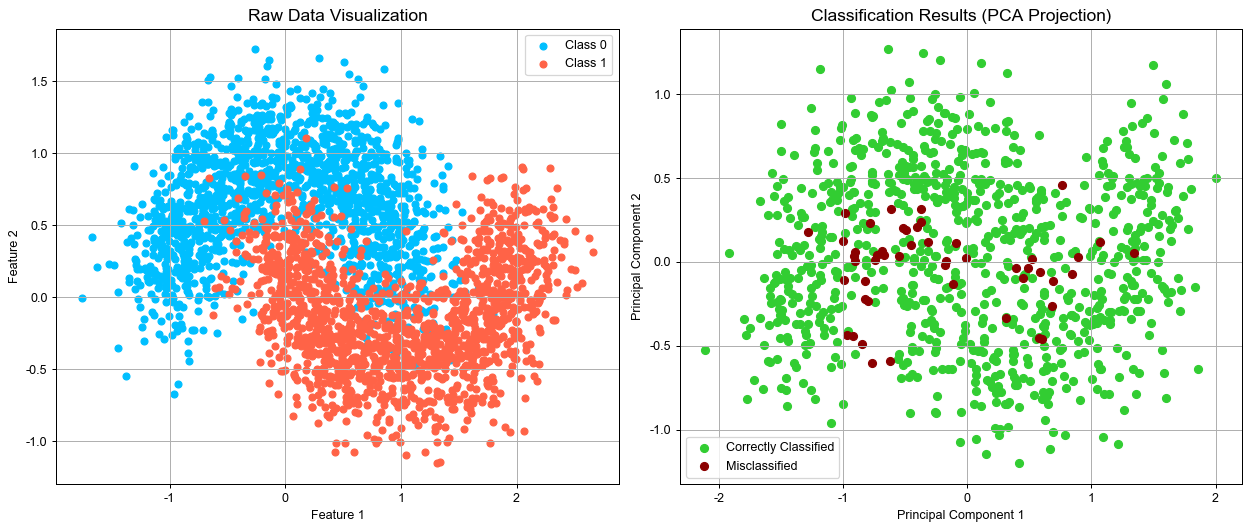

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

X_test_reduced = pca.transform(X_test)
correct = y_pred == y_test

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='deepskyblue', label='Class 0', s=30)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tomato', label='Class 1', s=30)
plt.title("Raw Data Visualization", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_test_reduced[correct, 0], X_test_reduced[correct, 1], c='limegreen', label='Correctly Classified', s=40)
plt.scatter(X_test_reduced[~correct, 0], X_test_reduced[~correct, 1], c='darkred', label='Misclassified', s=40)
plt.title("Classification Results (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

### 6. 模型优化：超参数调优

#### 网格搜索调参

我们可以对 `C` 和 `σ` 做网格搜索优化：

In [7]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
# 包装原始特征到核矩阵的转换，避免 SVC 的 pairwise 标签使 CV 误切矩阵。
class LapSVC(ClassifierMixin, BaseEstimator):
    def __init__(self, sigma=1.0, C=1.0):
        self.sigma = sigma
        self.C = C
    def fit(self, X, y):
        self.X_fit_ = np.asarray(X)
        self.estimator_ = SVC(kernel='precomputed', C=self.C)
        self.estimator_.fit(laplacian_kernel(self.X_fit_, self.X_fit_, self.sigma), y)
        self.classes_ = self.estimator_.classes_
        self.n_features_in_ = self.X_fit_.shape[1]
        return self
    def predict(self, X):
        return self.estimator_.predict(laplacian_kernel(np.asarray(X), self.X_fit_, self.sigma))
param_grid = {'sigma': [0.1, 0.5], 'C': [0.1, 1.0]}
model = GridSearchCV(LapSVC(), param_grid, cv=5, error_score='raise')
model.fit(X_train, y_train)

,estimator,LapSVC()
,param_grid,"{'C': [0.1, 1.0], 'sigma': [0.1, 0.5]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,sigma,0.5


#### 输出最佳参数与精度

In [8]:
print("最佳参数：", model.best_params_)
print("最佳分数：", model.best_score_)

最佳参数： {'C': 0.1, 'sigma': 0.5}
最佳分数： 0.9295238095238096


## 模型分析

### 优缺点

**优点**

1. **对离群点更鲁棒**：拉普拉斯核使用的是 **L1范数（曼哈顿距离）**，相比高斯核使用的L2距离（欧几里得距离），在处理包含异常值的数据时更加稳定，不容易被极端值“拉远”。
2. **能捕捉稀疏结构和局部模式**：在如“半月型”或“环形”这样局部结构突出的数据中，拉普拉斯核表现优秀，因为它对近邻非常敏感，对远离的点快速“忽略”。
3. **数学形式简洁，计算效率相对高**：相比一些更复杂的非线性核，拉普拉斯核的计算较为直观，尤其适合快速原型验证。
4. **适合用于分类任务中的稀疏特征空间**：如果你的特征很多是稀疏（如文本向量或某些基因数据），L1核比L2更自然地建模“非零差异”。

**缺点**

1. **不总是满足Mercer条件（正定核要求）**：并非所有情况下拉普拉斯核都能保证正定，可能导致某些SVM实现中的数值不稳定或收敛性差。
2. **参数σ敏感，需要调优**：拉普拉斯核对参数 **σ** 十分敏感，σ太大就变成常数核，太小则过拟合，必须配合交叉验证寻找最优值。
3. **泛化能力依赖数据分布**：在一些边界模糊、类间重叠较大的数据上，拉普拉斯核可能无法有效划分边界。
4. **对高维空间可能欠拟合**：当数据维度非常高（比如图像或文本向量化后维度上千），L1距离对每个维度的变化不如L2表现得明显，可能影响精度。

### 与相似算法对比

| 核方法 / 算法 | 距离度量 | 对异常值鲁棒 | 捕捉局部结构 | 参数调优难度 | 应用领域 |
|-|-|-|-|-|-|
| **拉普拉斯核（L1-RBF）** | L1曼哈顿距离 | 很强 | 很好 | 需要调σ | 图像边缘、稀疏数据、局部判别场景 |
| **高斯核（RBF）** | L2欧几里得距离 | 一般 | 一般 | 需要调γ | 通用型非线性分类 |
| **多项式核（Poly）** | 多项式映射 | 一般 | 差 | 较复杂 | 图像识别、对称数据场景 |
| **线性核（Linear）** | 无非线映射 | 强 | 差 | 易调参 | 文本分类、大规模数据 |
| **Sigmoid核** | 双曲映射 | 不稳定 | 较差 | 容易失效 | 神经网络模拟、实验性研究 |

### 何时选用拉普拉斯核？何时考虑替代？

### 优选拉普拉斯核的情况

- 你面对的是 **具有清晰边界、局部性强的数据**，例如：

  - 图像中的边缘检测、纹理识别；
  - 有“岛状”分布的聚类样本；
- 数据中可能存在 **部分离群点或异常值**；
- 你期望模型对「特征差异」的变化非常敏感（比如异常检测）；
- 特征空间是稀疏的，如文本、基因芯片分析。

### 考虑使用其他核的情况

- 如果你的数据是 **高维连续特征**（如图片像素），可以尝试 **高斯核**；
- 如果你的任务是 **大规模线性可分的文本分类**，优先使用 **线性核**；
- 如果你发现模型调参非常困难、过拟合严重，可以选择更稳健的 **高斯核**；
- 如果你需要对输入数据的“角度”更敏感（如形状匹配），考虑 **多项式核**。

拉普拉斯核是一个“快速灵敏型”的非线性核方法，适用于对局部差异敏感、结构清晰的任务，但需要合理调参和注意其数值稳定性。